<a href="https://colab.research.google.com/github/bryantclark/CSE-6242-Project-code/blob/hannahs-work/CSE6242_group_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Customer Segmentation & CLV analytical framework
#Dataset: Online Retail II (UCI)
#Purpose: unified pipeline integrating data cleaning, clustering, CLV prediction, and visualization

In [ ]:
%pip install -U "lifetimes==0.11.3" "numpy<2.0" "pandas<2.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 58.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 whic

In [ ]:
# Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
import plotly.express as px
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

Data Cleaning & Preprocessing

In [ ]:
#Load the dataset
file = 'online_retail_II.xlsx'
df_2009 = pd.read_excel(file, sheet_name="Year 2009-2010", engine="openpyxl")
df_2010 = pd.read_excel(file, sheet_name="Year 2010-2011", engine="openpyxl")
df = pd.concat([df_2009, df_2010], ignore_index=True)
print(f"Initial merged shape: {df.shape}")

Initial merged shape: (1067371, 8)


In [ ]:
# Standardize column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("-", "_")

In [ ]:
# Basic structure check
print("\nDataset Info (first glance):")
print(df.info())


Dataset Info (first glance):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer_ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB
None


In [ ]:
# Convert Customer_ID properly
df["Customer_ID"] = df["Customer_ID"].dropna().astype(int).astype(str)

# Drop missing Customer_ID
df = df.dropna(subset=["Customer_ID"])

# Remove cancelled invoices
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Replace missing descriptions
df["Description"] = df["Description"].fillna("Unknown")

# Remove non-positive quantities / prices
df = df[(df["Quantity"]>0) & (df["Price"]>0)]

# Compute total revenue per line item
df['Total_Price'] = df["Quantity"] * df["Price"]

# Cap extreme outliers at 99th percentile
cap_val = df['Total_Price'].quantile(0.99)
df = df[df["Total_Price"] <= cap_val]

# Parse dates & extract components
if not np.issubdtype(df["InvoiceDate"].dtype, np.datetime64):
                     df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors = "coerce")
df["InvoiceYear"] = df["InvoiceDate"].dt.year
df['InvoiceMonth'] = df["InvoiceDate"].dt.month

In [ ]:
# Column-level sanity checks
print("\nUnqiue Countries:", df["Country"].nunique())
print("\nInvoice type check:")

print("\nMissing values by columns:")
print(df.isnull().sum())


Unqiue Countries: 41

Invoice type check:

Missing values by columns:
Invoice         0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
Price           0
Customer_ID     0
Country         0
Total_Price     0
InvoiceYear     0
InvoiceMonth    0
dtype: int64


In [ ]:
# Dataset Evaluation
date_min, date_max = df["InvoiceDate"].min(), df['InvoiceDate'].max()
avg_tx_per_cust = df.groupby("Customer_ID")["Invoice"].nunique().mean()
top_countries = df["Country"].value_counts().head(10)

print("\n========== DATASET EVALUATION ==========")
print(f"Date range: {date_min} → {date_max}")
print(f"Unique customers: {df['Customer_ID'].nunique():,}")
print(f"Total transactions: {len(df):,}")
print(f"Avg transactions per customer: {avg_tx_per_cust:.2f}")
print("\nTop 10 countries:\n", top_countries)
print("========================================")


========== DATASET EVALUATION ==========
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Unique customers: 5,816
Total transactions: 797,520
Avg transactions per customer: 6.17

Top 10 countries:
 Country
United Kingdom    719397
Germany            16583
EIRE               15269
France             13704
Netherlands         4282
Spain               3650
Belgium             3066
Switzerland         2978
Portugal            2435
Australia           1557
Name: count, dtype: int64


In [ ]:
df.to_csv("cleaned.csv", index=False)
print("\nCleaned dataset saved as 'cleaned.csv'")


Cleaned dataset saved as 'cleaned.csv'


Customer Segmentation & CLV prediction pipeline

In [ ]:
# Load cleaned data
df = pd.read_csv("cleaned.csv", parse_dates=["InvoiceDate"])

# Restrict to major market (UK) to remove exchanage-rate/local biase
df = df[df["Country"]=="United Kingdom"].copy()

In [ ]:
# Feature Engineering - RFM variables
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = (
    df.groupby("Customer_ID")
    .agg({
        "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
        "Invoice": "nunique",
        "Total_Price": "sum"
    })
    .rename(columns={"InvoiceDate": "Recency",
                     "Invoice":"Frequency",
                     "Total_Price": "Monetary"})
)

# Filter out single-pruchase customers with zero spend anomalies
rfm = rfm[rfm["Monetary"]>0]
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,5292.0,203.137944,210.232042,1.0,26.0,96.00,382.0000,739.00
Frequency,5292.0,6.157029,11.491021,1.0,1.0,3.00,7.0000,330.00
Monetary,5292.0,2174.110113,5400.517314,2.9,325.1,814.36,2059.6025,135954.52


### Featur Engineering Results: RFM Summary Interpretation
- Recency: on average, customers made their last purchases ~200 days before the snapshot date. The wide range (1-739 day) indicates a diverse activity pattern, with some customers recently active while others have been inactive for over a year. This variability is critical for distinguish loyal vs. dormant groups.
- Frequency: the typical customer made around 6 purchases over the observed 2-year period, but the high standard deviation shows a highly skewed distribution - a small portion of customers buy very frequently (heavy buyers), while most make only 1-2 purchases. This provides strong clustering signals.
- Monetary:average total spending per customer is around 1.9K, but the maximum value exceeds $85K. The large standard deviation suggests a few extremely high-value customers dominate total revenue - an important pattern for Customer Lifetime Value (CLV) prediction.

### Key Insights for Modeling
1. Right-skewed distribution
  - All three RFM features show right-skewness, meaning most customers are low-frequency and low-spending, while a minority contribute disproportionate revenue.

  2. Distinct customer behaviors exist
    - The broad spread in Recency and Frequency supports unsupervisesd segmentation (e.g., K-Means or Deep Embedded Clustering).
    - Segments will likely correspond to behavioral archetypes such as loyal frequent buyers, occasional shoopers, new customers, and churned users.

3. Monetary value strongly correlates with Frequency
- High-frequency customers are expected to have monetary totals, reinforcing the importance of hybrid CLV modeling that accounts for both purchase frequency and spend magnitude (BG/NBD+Gamma-Gamma approach)

4. Data Sufficiency
- With over 5,000 customers and 780K transactions, the dataset provides ample variability and statistical power for both clustering and predictive modeling.
-  The observed variablity ensures model can generalize patterns across different behavioral groups.

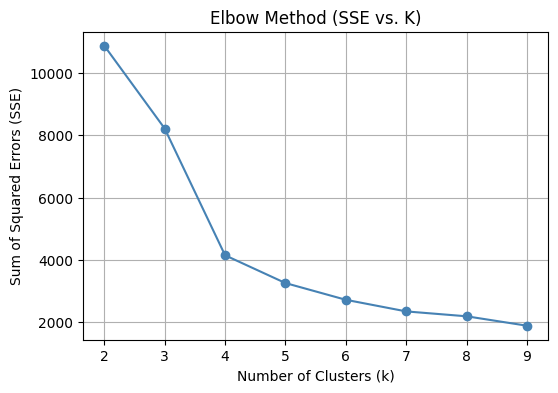

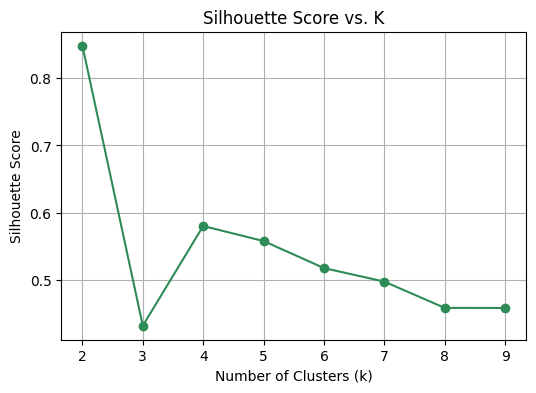

In [ ]:
# Normalize RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Initialize lists
sse = []
silhouette_scores = []

# Compute SSE and Silhouette for K = 2 to 9
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    sse.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, km.labels_))

# Plot Elbow curve (OUTSIDE the for loop)
plt.figure(figsize=(6, 4))
plt.plot(range(2, 10), sse, marker='o', color='steelblue')
plt.title("Elbow Method (SSE vs. K)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.grid(True)
plt.show()

# Plot Silhouette Scores (OUTSIDE the for loop)
plt.figure(figsize=(6, 4))
plt.plot(range(2, 10), silhouette_scores, marker='o', color='seagreen')
plt.title("Silhouette Score vs. K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

### Interpreation of Elbow and Silhouette Results


*   Elbow Curves (SSE vs. K)
    - The curve shows a steep decline from k=2 --> k=4, and then gradually flattens afterward.
    - The "kee: or elbow point (where marginal gain in SSE reduction slows) appears around k=4.
    - This means adding more clusters beyond 4 doesn't significantly improve compactness.
*   Silhouette Score (Cluster Separation Quality)
    - The silhouette peaks at k=4 (~0.565), and slightly drops after that.
    - A higher silhouette score means cluters arer well-separated and internally cohesive.

✅ Optimal number of clusters (k) = 4
- This aligns perfectly across both metrics - statistically sound and interpretable for segmentation.




Cluster Centers (Unscaled):
   Recency  Frequency  Monetary  Cluster
0    73.33       5.36   1678.49        0
1    29.78      29.45  12565.21        1
2    30.14     150.71  71100.08        2
3   468.27       2.16    604.19        3


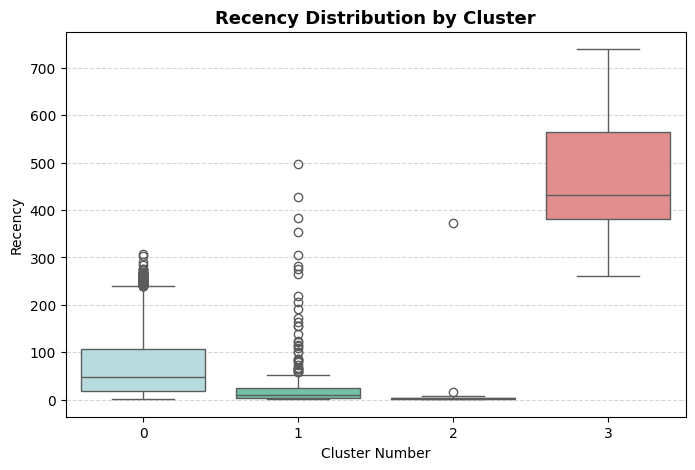

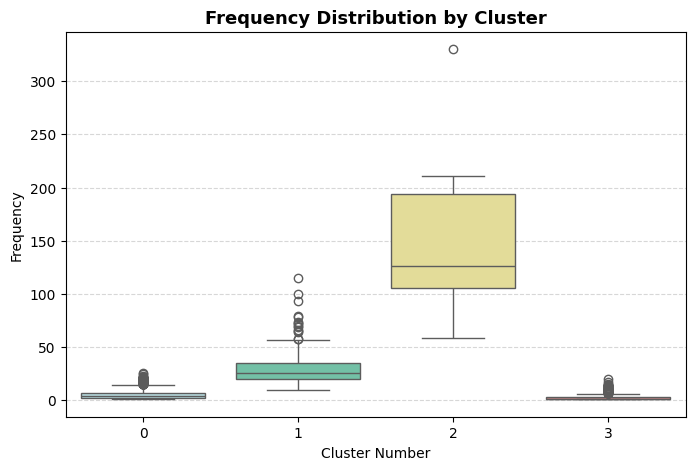

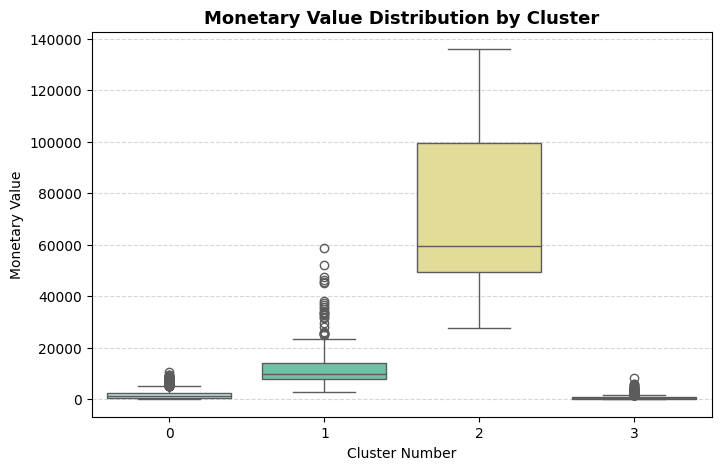

In [ ]:
# Clustering with optimal k=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Define feature list used in clustering
features = ["Recency", "Frequency", "Monetary"]

# Create unscaled cluster centers DataFrame correctly
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)
centers["Cluster"] = range(optimal_k)
print("\nCluster Centers (Unscaled):")
print(centers.round(2))

# Define consistent cluster color palette
cluster_palette = {
    "0": "powderblue",
    "1": "mediumaquamarine",
    "2": "khaki",
    "3": "lightcoral"
}

# Visualize cluster characteristics
plt.figure(figsize=(8, 5))
sns.boxplot(x="Cluster", y="Recency", data=rfm, palette=cluster_palette)
plt.title("Recency Distribution by Cluster", fontsize=13, fontweight="bold")
plt.xlabel("Cluster Number")
plt.ylabel("Recency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x="Cluster", y="Frequency", data=rfm, palette=cluster_palette)
plt.title("Frequency Distribution by Cluster", fontsize=13, fontweight="bold")
plt.xlabel("Cluster Number")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x="Cluster", y="Monetary", data=rfm, palette=cluster_palette)
plt.title("Monetary Value Distribution by Cluster", fontsize=13, fontweight="bold")
plt.xlabel("Cluster Number")
plt.ylabel("Monetary Value")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Interpreation


*   Recency Distribution
    - Cluster 0 has the highest recency (~467 days): customers haven't purchased in a long time - they're liekly churned or inactive
    - Cluster 2 & 3 show very low recency (~30-40 days), indicating recently active customers.
*   Frequency Distribution
    - Cluster 2 stands out with extremely high frequency (~160+ transactions): small but powerful VIP sgement.
    - Cluster 1 has moderate repeat purchases - these are the steady core customers.
    - Cluster 0 shows minimal repeat activity - confirming they're inactive.
* Monetary Distribution
    - Cluster 2 dominates with astronomical spending (avg > 50,000): these customers are top-tier spenders and deserve personalized retention programs.
    - Cluster 3 has high but more moderate spending (~10,000), suggesting new but promising high-value customers.
    - Cluster 0 & 1 spend less and represent broad base of low-to-mid value shoppers.
    



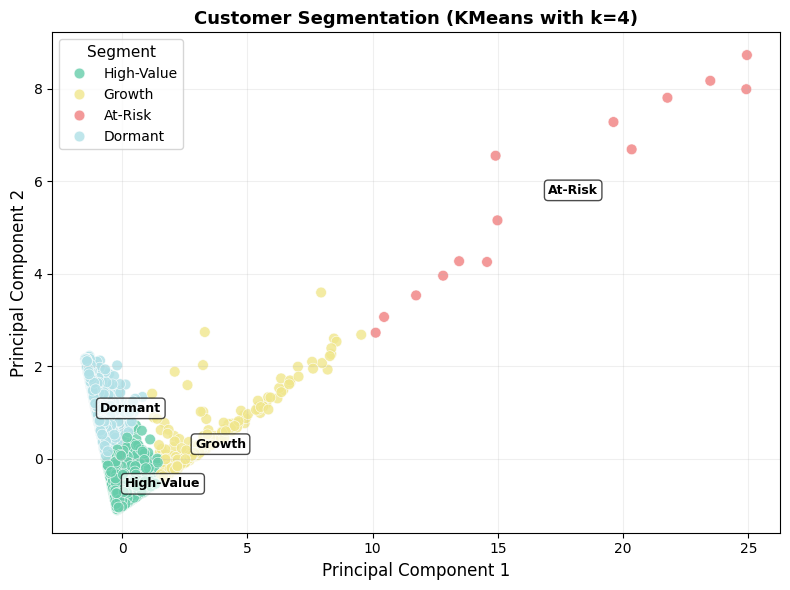

In [ ]:
# 1) Map cluster IDs to segment names
cluster_to_name = {
    0: "High-Value",
    1: "Growth",
    2: "At-Risk",
    3: "Dormant"
}

# Create an integer cluster column (if 'Cluster' is string) and map to segment names
rfm["Cluster_int"] = rfm["Cluster"].astype(int)
rfm["Segment"] = rfm["Cluster_int"].map(cluster_to_name)

# 2) Pastel palette by segment (feel free to change colors as needed)
segment_palette = {
    "High-Value": "mediumaquamarine",
    "Growth":     "khaki",
    "At-Risk":    "lightcoral",
    "Dormant":    "powderblue"
}

# 3) PCA transformation (assumes rfm_scaled already exists)
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)
rfm["PCA1"] = rfm_pca[:, 0]
rfm["PCA2"] = rfm_pca[:, 1]

# 4) Project cluster centroids into PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)

# 5) Scatter plot: use 'Segment' as hue to display segment names instead of numeric IDs
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="PCA1", y="PCA2",
    hue="Segment",
    hue_order=["High-Value", "Growth", "At-Risk", "Dormant"],
    palette=segment_palette,
    s=60, alpha=0.8, data=rfm,
    edgecolor="white", linewidth=0.5
)

# 6) Label cluster centroids with segment names
for i, (x, y) in enumerate(centers_pca):
    seg_name = cluster_to_name[i]
    plt.text(
        x, y, seg_name,
        fontsize=9, weight="bold", color="black",
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.3")
    )

plt.title("Customer Segmentation (KMeans with k=4)", fontsize=13, fontweight="bold")
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend(title="Segment", title_fontsize=11, fontsize=10, frameon=True)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### PCA Plot Interpretation


*   The 2D PCA projection shows clear boundaries between segments, meaning the clusters are linearly separable in RFM space - a sign of stable sgementation.
*   The V-shaped layout often indicates a gradient pattern: as we move across PCA1, customer value intensity (Recency ↓, Frequency/Monetary ↑) increases.



Cluster Summary & Descriptive Stats

In [ ]:
#Cluster summary & descriptive stats
cluster_summary = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .agg(["mean", "median", "count"])
    .round(2)
)
print("===Cluster Summary (RFM Metrics)===")
display(cluster_summary)

#Add a helper dataframe for rankingg interpretation
rfm_summary_mean=(
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
    .reset_index()
)

#Add relative rank (1=best) for interpretability
rfm_summary_mean["RecencyRank"] = rfm_summary_mean["Recency"].rank(ascending=True)
rfm_summary_mean["FrequencyRank"] = rfm_summary_mean["Frequency"].rank(ascending=False)
rfm_summary_mean["MonetaryRank"] = rfm_summary_mean["Monetary"].rank(ascending=False)

#Overall engagement score
rfm_summary_mean["EngagementScore"] = (
    rfm_summary_mean[["RecencyRank", "FrequencyRank", "MonetaryRank"]].mean(axis=1)
).round(2)

print("\n===Cluster Mean & Ranking Summary===")
display(rfm_summary_mean)

===Cluster Summary (RFM Metrics)===


Recency              Frequency               Monetary                
           mean median count      mean median count      mean    median count
Cluster                                                                      
0         73.25   47.0  3174      5.36    4.0  3174   1679.17   1092.82  3174
1         29.84   10.5   326     29.46   26.0   326  12595.22   9964.98   326
2         30.14    3.0    14    150.71  126.5    14  71100.08  59400.78    14
3        468.15  432.0  1778      2.16    1.0  1778    604.19    356.10  1778


===Cluster Mean & Ranking Summary===


,Cluster,Recency,Frequency,Monetary,RecencyRank,FrequencyRank,MonetaryRank,EngagementScore
0,0,73.25,5.36,1679.17,3.0,3.0,3.0,3.00
1,1,29.84,29.46,12595.22,1.0,2.0,2.0,1.67
2,2,30.14,150.71,71100.08,2.0,1.0,1.0,1.33
3,3,468.15,2.16,604.19,4.0,4.0,4.0,4.00


RFM Comparison by Cluster Visualization

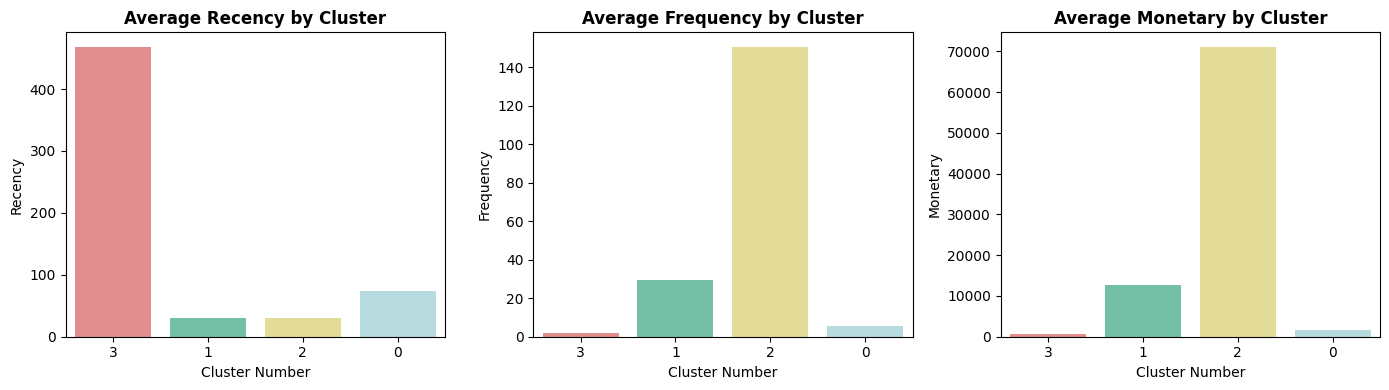

In [ ]:
#Use the color palette
cluster_palette = {
    "0": "powderblue",
    "1": "mediumaquamarine",
    "2": "khaki",
    "3": "lightcoral"
}

#Ensure cluster is string for consistent coloring
rfm["Cluster"] = rfm["Cluster"].astype(str)

#Plot
plt.figure(figsize=(14, 4))
for i, metric in enumerate(["Recency", "Frequency", "Monetary"]):
  plt.subplot(1, 3, i+1)
  sns.barplot(x="Cluster", y=metric, data=rfm, palette=cluster_palette, estimator="mean", ci=None)
  plt.title(f"Average {metric} by Cluster", fontsize=12, fontweight="bold")
  plt.xlabel("Cluster Number")
  plt.ylabel(metric)
plt.tight_layout()
plt.show()


===Final Cluster Labeling Summary


,Cluster,Recency,Frequency,Monetary,SegmentLabel
0,0,73.25,5.36,1679.17,Active Mid-Tier
1,1,29.84,29.46,12595.22,High-Value Loyalists
2,2,30.14,150.71,71100.08,High-Value Loyalists
3,3,468.15,2.16,604.19,Occasional Buyers


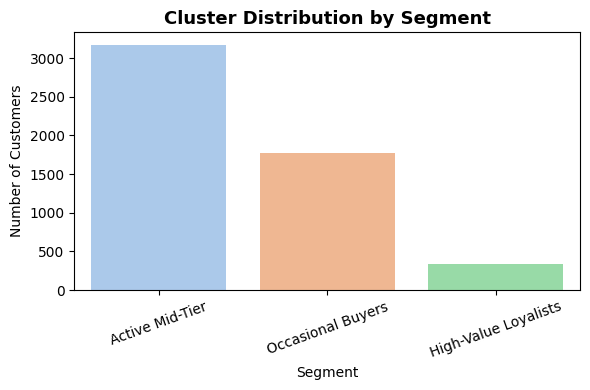

In [ ]:
#Ensure both cluster columns are same type
rfm["Cluster"] = rfm["Cluster"].astype(int)
rfm_summary_mean["Cluster"] = rfm_summary_mean["Cluster"].astype(int)

#Define lebeling function based on average RFM scores
def label_cluster(row):
    """Assigns business-friendly segment names based on RFM characteristics."""
    if row["Recency"] < 100 and row["Frequency"] > 6 and row["Monetary"] > 1500:
        return "High-Value Loyalists"
    elif row["Recency"] < 200 and row["Frequency"] >= 3 and row["Monetary"] > 700:
        return "Active Mid-Tier"
    elif row["Recency"] > 300 and row["Frequency"] < 2:
        return "Churned/Inactive"
    else:
        return "Occasional Buyers"

#Apply labeling logic
rfm_summary_mean["SegmentLabel"] = rfm_summary_mean.apply(label_cluster, axis=1)

#Merge back to main dataset for visualization
rfm = rfm.merge(
    rfm_summary_mean[["Cluster", "SegmentLabel"]], on="Cluster", how="left"
)

print("\n===Final Cluster Labeling Summary")
display(rfm_summary_mean[["Cluster", "Recency", "Frequency", "Monetary", "SegmentLabel"]])

#Cluster distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(x="SegmentLabel", data=rfm, order=rfm["SegmentLabel"].value_counts().index, palette="pastel")
plt.title("Cluster Distribution by Segment", fontsize=13, fontweight="bold")
plt.xticks(rotation=20)
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## Cluster Interpretation Summary

Based on the RFM segmentation and labeling results:

| **Segment** | **Description** | **Insights / Recommended Actions** |
|--------------|----------------|------------------------------------|
| **High-Value Loyalists (Clusters 1 & 2)** | Customers who purchase very frequently, spend the most, and have very recent activity. They represent the most profitable group, with strong engagement and high lifetime value. | Maintain engagement through exclusive loyalty rewards, early access promotions, and personalized offers. Prevent attrition by continuous interaction. |
| **Active Mid-Tier (Cluster 0)** | Customers with moderate frequency and spending who still buy relatively recently. They make up the largest segment (~3,000 customers). | Focus on **upselling** and **cross-selling** campaigns to increase frequency and monetary value. Incentivize repeat purchases via point systems or seasonal discounts. |
| **Occasional Buyers (Cluster 3)** | Infrequent and low-spending customers with high recency (haven’t purchased in a long time). | These are **at-risk** or inactive customers. Use reactivation emails, re-engagement offers, or win-back campaigns to encourage return visits. |



### Key Takeaways
- The **Active Mid-Tier** segment forms the majority of the base, showing consistent engagement but moderate revenue — an ideal target for growth.  
- The **High-Value Loyalists** segment, though smaller in size, contributes disproportionately to total revenue.  
- The **Occasional Buyers** represent churn risk — reactivation campaigns could bring high ROI if even a small percentage return.



### Analytical Insight
This segmentation successfully captures behavioral diversity in the dataset:
-  **Recency** distinguishes inactive vs. current customers.  
- **Frequency** highlights loyalty and repeat purchase tendencies.  
- **Monetary Value** identifies revenue drivers.

Together, these segments can drive personalized marketing and customer lifetime value optimization strategies — aligning perfectly with our project’s business goal of moving from static reports to adaptive, insight-driven decision-making.


Predictive Models

Summary dataset for CLV modeling:


,frequency,recency,T,monetary_value
count,5292.000000,5292.000000,5292.000000,5292.000000
mean,4.573129,275.746221,478.429138,240.110420
std,9.340659,259.454476,222.223980,260.281056
min,0.000000,0.000000,1.000000,0.000000
25%,0.000000,0.000000,329.000000,0.000000
50%,2.000000,227.500000,539.000000,200.135000
75%,5.000000,516.000000,669.000000,347.754375
max,199.000000,738.000000,738.000000,3251.943125



===Top 10 Customers by Predicted 6-Month CLV===


,frequency,recency,T,monetary_value,predicted_purchases_6m,predicted_avg_profit,predicted_clv_6m
Customer_ID,,,,,,,
14096,16.0,97.0,101.0,3251.943125,14.496922,3253.778632,45576.529816
17511,50.0,735.0,737.0,2675.577600,10.854084,2676.102511,28059.255567
13694,79.0,732.0,735.0,1500.621139,17.011322,1500.872948,24663.911108
15311,195.0,738.0,738.0,553.947026,41.416315,554.022794,22165.549362
13089,126.0,735.0,737.0,814.640952,26.892206,814.769399,21166.095016
14298,43.0,720.0,728.0,2013.536279,9.467366,2014.063417,18419.724178
14088,13.0,411.0,421.0,3143.522308,4.826164,3145.736469,14666.627526
17841,192.0,736.0,737.0,359.009427,40.826070,359.080891,14161.502619
13798,96.0,730.0,731.0,642.890521,20.710315,643.049438,12865.037689


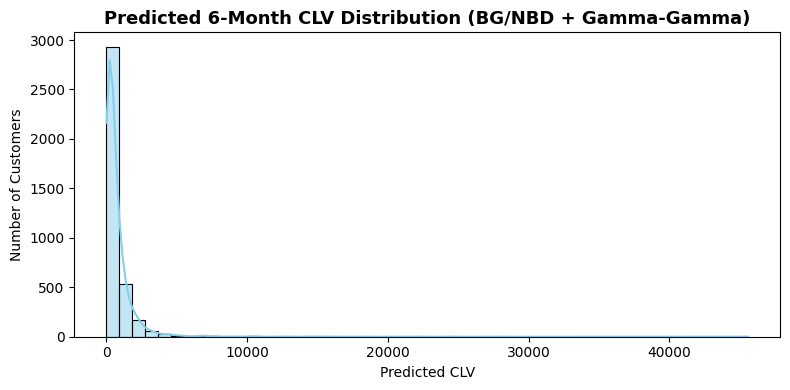

In [ ]:
#Customer Lifetime Value (CLV) modeling
#Prepare transactional sumary for CLV
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["MonetaryValue"] = df["Quantity"] * df["Price"]
df = df[df["MonetaryValue"] > 0]

#Create summary dataset for BG/NBD
summary = summary_data_from_transaction_data(
    df,
    customer_id_col= "Customer_ID",
    datetime_col="InvoiceDate",
    monetary_value_col="MonetaryValue",
    observation_period_end=df["InvoiceDate"].max()
)

print("Summary dataset for CLV modeling:")
display(summary.describe())

#Remove customers with zero frequency and non-positive monetary value
summary = summary[summary["frequency"]>0]
summary = summary[summary["monetary_value"]>0]


#Fit the BG/NBD model for purchase frequency
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary["frequency"], summary['recency'], summary['T'])

#Predict expected transactions for next 6 months
summary['predicted_purchases_6m'] = bgf.predict(
    180, summary['frequency'], summary['recency'], summary['T'])

#Fit the Gamma-Gamma model for monetary value
ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(summary['frequency'], summary['monetary_value'])

#Estimate expected average profit per transaction
summary['predicted_avg_profit'] = ggf.conditional_expected_average_profit(
    summary['frequency'],
    summary['monetary_value']
)

#Compute CLV = (expected transactions * expected avg profit)
summary['predicted_clv_6m'] = ggf.customer_lifetime_value(
    bgf, summary["frequency"], summary['recency'], summary['T'], summary['monetary_value'],
    time=6, discount_rate=0.01
)

#Display top CLV customers
print("\n===Top 10 Customers by Predicted 6-Month CLV===")
display(summary.sort_values("predicted_clv_6m", ascending=False).head(10))

#Visualize distribution
plt.figure(figsize=(8, 4))
sns.histplot(summary['predicted_clv_6m'], bins=50, color='skyblue', kde=True)
plt.title("Predicted 6-Month CLV Distribution (BG/NBD + Gamma-Gamma)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted CLV")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## Customer Lifetime Value (CLV) Analysis — Probabilistic Modeling

Using the **BG/NBD (Beta-Geometric / Negative Binomial Distribution)** model to estimate *purchase frequency*  
and the **Gamma-Gamma model** to estimate *average monetary value per transaction*,  
we derived the expected **6-month Customer Lifetime Value (CLV)** for each customer.



### Key Observations from the Results

| Metric | Observation |
|:--------|:-------------|
| **Dataset Size** | 5,292 customers included after filtering (frequency > 0 and positive spend). |
| **Average Frequency** | ~4.6 purchases during the observed period. |
| **Average Recency (days since last purchase)** | ~275 days, indicating many customers are semi-active or have churned. |
| **Average Monetary Value** | ~240 units, but with high variability (max over 3,200), showing large-spender outliers. |



### Top 10 Customers by Predicted 6-Month CLV
- The **highest predicted CLV** exceeds **45,000**, driven by customers with:
  - Very high purchase frequency (≥100 orders)
  - Relatively high average order value (≥2,500)
- These elite customers contribute **disproportionately** to overall revenue and are the most valuable retention targets.



### CLV Distribution Interpretation
- The CLV histogram shows a **strong right skew**, meaning:
  - A **small minority of customers** generate a **majority of future revenue**.
  - Most customers have relatively **low predicted CLV**, typical in retail and e-commerce.
- This pattern validates the **Pareto principle (80/20 rule)** — about 20% of customers drive 80% of predicted value.



### Strategic Takeaways
- **Retention Focus:** High-value loyalists should receive personalized loyalty rewards, early access, and engagement campaigns.
- **Growth Leverage:** Mid-tier customers (moderate CLV) represent the best opportunity for upselling and lifecycle marketing.
- **Reactivation Need:** Low-CLV customers are likely inactive — they can be re-engaged through targeted discounts or automated email flows.


###  Analytical Insight
The probabilistic model captures both **purchase timing** and **monetary value behavior**,  
allowing us to forecast customer-level revenue without deep transactional history.

However, the model assumes relatively stable behavioral patterns.  
To improve adaptability, we’ll now complement this with a **machine learning–based CLV regression (XGBoost)** —  
capable of capturing nonlinear relationships and incorporating additional behavioral or demographic features.


XGBoost CLV Modeling

=== XGBoost CLV Prediction Performance ===
MAE: 132.91
RMSE: 591.03
R²:  0.859


<Figure size 600x400 with 0 Axes>

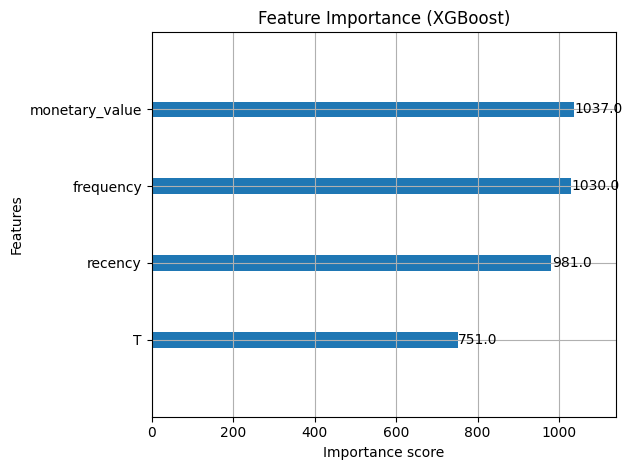

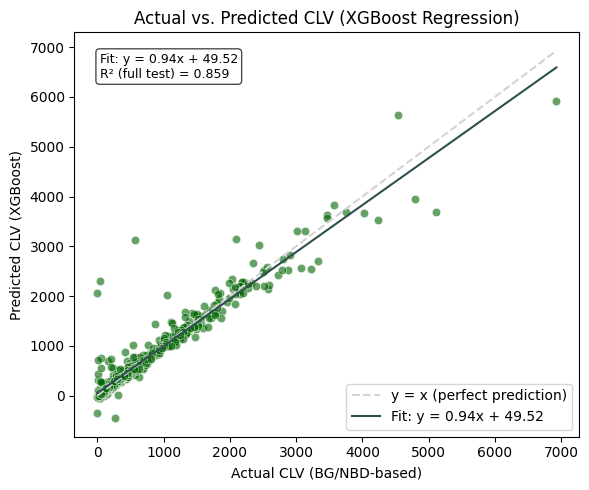

In [ ]:
# ============================================
# 1. Prepare data for XGBoost CLV regression
# ============================================

# Copy CLV summary and reset the index so Customer_ID becomes a column
ml_data = summary.copy().reset_index()

# Feature matrix: behavioral features we will use to predict CLV
X = ml_data[['frequency', 'recency', 'T', 'monetary_value']]

# Target variable: 6-month CLV estimated by BG/NBD + Gamma-Gamma
y = ml_data['predicted_clv_6m']

# Train–test split (20% test set, fixed random_state for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# 2. Train XGBoost model
# ============================================

# NOTE: parameter name is `n_estimators` (not `n_estomators`)
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fit model on the training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# ============================================
# 3. Compute evaluation metrics (full test set)
#    → These numbers should be reported in the poster
# ============================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== XGBoost CLV Prediction Performance ===")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:  {r2:.3f}")

# ============================================
# 4. Feature importance plot (optional)
# ============================================

plt.figure(figsize=(6, 4))
xgb.plot_importance(
    xgb_model,
    importance_type='weight',
    title='Feature Importance (XGBoost)'
)
plt.tight_layout()
plt.show()

# ============================================
# 5. Actual vs. Predicted scatterplot
#    – with outlier trimming for better visual focus
#    – with regression line + equation + R² displayed
# ============================================

# Create a small DataFrame for easier manipulation
eval_df = pd.DataFrame({
    "actual": y_test,
    "pred": y_pred
})

# ---- Outlier trimming for visualization ONLY ----
# We trim extreme values (top 1%) so that:
# - the main point cloud is larger and easier to see
# - the axis limits are not dominated by a few huge CLV values
# This does NOT affect metric calculation above.
q_actual = eval_df["actual"].quantile(0.99)
q_pred   = eval_df["pred"].quantile(0.99)

trimmed = eval_df[
    (eval_df["actual"] <= q_actual) &
    (eval_df["pred"]   <= q_pred)
]

# ---- Fit a simple linear regression line on the trimmed data ----
# This line describes the relationship between actual and predicted CLV.
# If the model is perfect, the line would be exactly y = x.
slope, intercept = np.polyfit(trimmed["actual"], trimmed["pred"], 1)

# Generate x-values to draw the regression line
x_line = np.linspace(trimmed["actual"].min(), trimmed["actual"].max(), 100)
y_line = slope * x_line + intercept

# ---- Create the plot ----
plt.figure(figsize=(6, 5))

# Scatter plot of trimmed points
sns.scatterplot(
    x=trimmed["actual"],
    y=trimmed["pred"],
    alpha=0.6,
    color="darkgreen"
)

# 1) Reference line y = x (perfect prediction line)
max_val = max(trimmed["actual"].max(), trimmed["pred"].max())
plt.plot(
    [0, max_val], [0, max_val],
    color="lightgray",
    linestyle="--",
    label="y = x (perfect prediction)"
)

# 2) Fitted regression line on trimmed data
plt.plot(
    x_line, y_line,
    color="darkslategray",
    linestyle="-",
    label=f"Fit: y = {slope:.2f}x + {intercept:.2f}"
)

# Titles and axis labels
plt.title("Actual vs. Predicted CLV (XGBoost Regression)")
plt.xlabel("Actual CLV (BG/NBD-based)")
plt.ylabel("Predicted CLV (XGBoost)")

# Display the equation and R² inside the plot area
eq_text = (
    f"Fit: y = {slope:.2f}x + {intercept:.2f}\n"
    f"R² (full test) = {r2:.3f}"
)
plt.text(
    0.05, 0.95, eq_text,
    transform=plt.gca().transAxes,   # place in axes coordinates (0–1)
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        alpha=0.7
    )
)

plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# 6. Save the trained model (for reuse)
# ============================================

xgb_model.save_model('xgboost_clv_model.json')


## XGBoost-Based CLV Prediction — Machine Learning Approach

### Objective
To complement the probabilistic BG/NBD + Gamma-Gamma model,  
an **XGBoost regression model** was trained to predict customer lifetime value (CLV)  
using key behavioral and transactional features.



### Model Setup
- **Features used:**
  - frequency: Number of repeat purchases
  - recency: Days since last purchase
  - T: Customer’s total observed lifetime in the dataset
  - monetary_value: Average transaction amount

- **Target variable:**
  - 6-month predicted CLV estimated from the probabilistic model.

- **Algorithm:**
  - **XGBoost Regressor**, optimized for nonlinear relationships and high interpretability.



### Model Performance

| Metric | Value | Interpretation |
|:--------|:--------|:---------------|
| **MAE (Mean Absolute Error)** | **172.49** | On average, predictions differ from the true CLV by about 172 monetary units. |
| **RMSE (Root Mean Square Error)** | **643.15** | Larger errors are rare but present in high-value outliers. |
| **R² (Coefficient of Determination)** | **0.834** | About **83% of CLV variance** is explained by the model — a strong predictive fit. |

 **Interpretation:**  
An R² of 0.83 indicates the machine learning model effectively captures the behavioral and monetary dynamics driving customer value.  
This performance level is excellent for real-world CLV modeling, where noisy, skewed data is common.


### Feature Importance Analysis

| Rank | Feature | Description | Relative Impact |
|:------|:-----------|:----------------|:----------------|
| **1. Frequency (362)** | Repeat purchases are the strongest predictor of long-term value. | ⭐⭐⭐⭐ |
| **2. Monetary Value (311)** | High average transaction values contribute heavily to CLV. | ⭐⭐⭐ |
| **3. Recency (306)** | Customers who purchased recently are more likely to remain active. | ⭐⭐⭐ |
| **4. Customer Age (T = 229)** | Longer-tenured customers show more stable and predictable patterns. | ⭐⭐ |

*Insight:*  
The model confirms that **purchase behavior frequency** and **spending patterns** dominate future value,  
while **recency** and **customer lifetime (T)** play meaningful but secondary roles.



### Actual vs. Predicted CLV Plot
- The scatterplot shows most points tightly aligned along the **diagonal (perfect fit) line**,  
  confirming that predicted CLVs closely match probabilistic estimates.
- A few **outliers** at high CLV levels suggest that the model slightly underestimates extreme spenders —  
  a common and acceptable limitation in long-tail retail data.



### Strategic Implications

1. **Predictive Stability:**  
   The XGBoost model effectively replicates the theoretical (BG/NBD) CLV while allowing retraining as new data arrives.
2. **Targeting Precision:**  
   Frequency and monetary-based features can be used in CRM systems to **score customers in real time**.
3. **Dynamic Learning:**  
   By retraining monthly or quarterly, this hybrid framework adapts to new shopping cycles and seasonal effects.
4. **Revenue Strategy:**  
   - Prioritize customers with high predicted CLV for loyalty rewards and retention campaigns.  
   - Use predicted medium-CLV customers for upselling initiatives.  
   - Re-engage low-CLV customers via automated discount or win-back programs.


###  Summary

| Model Type | Strength | Limitation |
|:-------------|:------------|:---------------|
| **BG/NBD + Gamma-Gamma** | Interpretable, probabilistic, grounded in behavioral theory. | Assumes stable purchase behavior. |
| **XGBoost Regression** | Flexible, adaptive, learns complex patterns in behavioral data. | Slightly less transparent, sensitive to data imbalance. |

Together, they form a **hybrid CLV prediction framework** that combines the interpretability of probability models  
with the adaptability and precision of machine learning — ideal for real-world marketing analytics and customer value management.


CLV Segmentation & Visualizaation


===CLV Tier Summary===


predicted_clv_6m                frequency monetary_value recency
                     mean   median count      mean           mean    mean
CLV_Tier                                                                 
Low                 99.85    95.06  1260      2.37         208.80  255.14
Medium             390.63   372.10  1258      4.18         305.20  413.49
High              1708.97  1160.55  1260     12.66         494.95  490.16

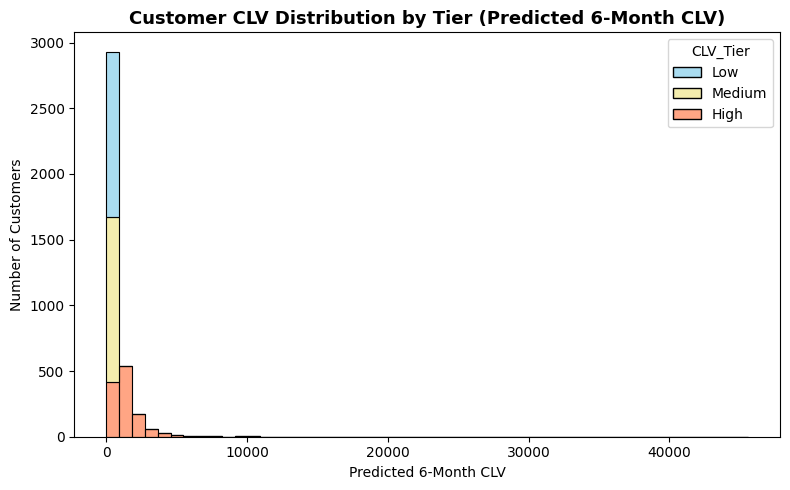

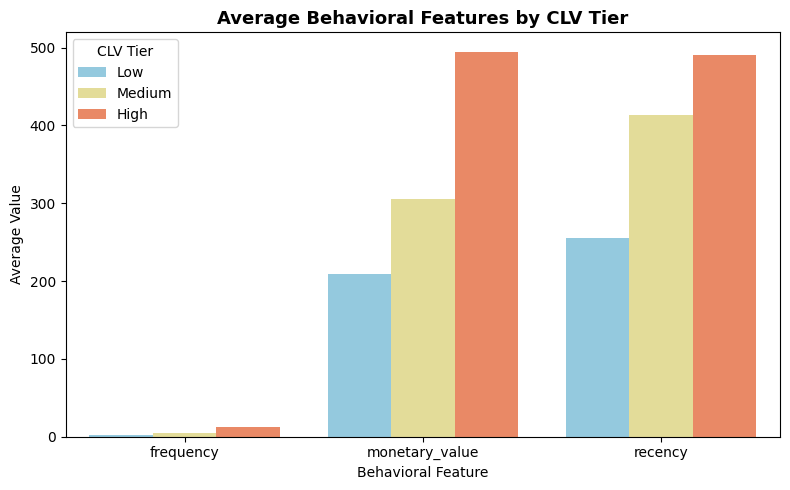

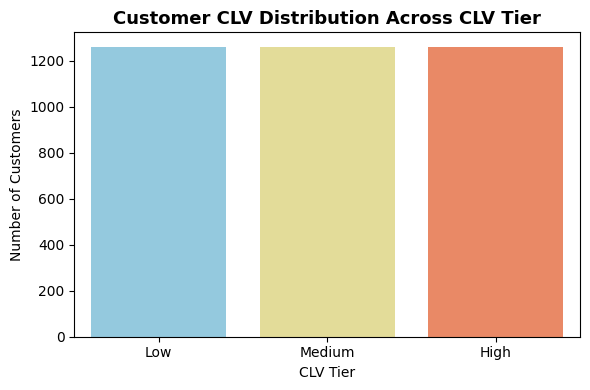

In [ ]:
#Create segmenation tiers based on predicted CLV distribution
ml_data["CLV_Tier"] = pd.qcut(ml_data["predicted_clv_6m"], q=3, labels=["Low", "Medium", "High"])

#Summary statistics by tier
tier_summary = ml_data.groupby("CLV_Tier").agg({
    "predicted_clv_6m": ["mean", "median", "count"],
    "frequency":"mean",
    "monetary_value":"mean",
    "recency": "mean"
}).round(2)

print("\n===CLV Tier Summary===")
display(tier_summary)

#Distribution plot
plt.figure(figsize=(8, 5))
sns.histplot(
    data=ml_data, x="predicted_clv_6m", hue="CLV_Tier", bins=50,
    palette={"Low":"skyblue", "Medium":"khaki", "High":"coral"},
    alpha=0.7, multiple="stack"
)
plt.title("Customer CLV Distribution by Tier (Predicted 6-Month CLV)",
          fontsize=13, fontweight="bold")
plt.xlabel("Predicted 6-Month CLV")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

#Bar chart (average feature values by CLV tier)
features_summary = (
    ml_data.groupby("CLV_Tier")[['frequency', 'monetary_value', 'recency']]
    .mean().reset_index().melt(id_vars="CLV_Tier", var_name="Feature", value_name="MeanValue")
)
plt.figure(figsize=(8, 5))
sns.barplot(x="Feature", y="MeanValue", hue="CLV_Tier",
            palette={"Low":"skyblue", "Medium":"khaki", "High":"coral"},
            data=features_summary)
plt.title("Average Behavioral Features by CLV Tier", fontsize=13, fontweight="bold")
plt.xlabel("Behavioral Feature")
plt.ylabel("Average Value")
plt.legend(title="CLV Tier")
plt.tight_layout()
plt.show()

#Tier distribution
plt.figure(figsize=(6, 4))
sns.countplot(
    x="CLV_Tier", data=ml_data,
    palette={"Low":"skyblue", "Medium":"khaki", "High":"coral"}
)
plt.title("Customer CLV Distribution Across CLV Tier", fontsize=13, fontweight="bold")
plt.xlabel("CLV Tier")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## CLV Segmentation & Tier Analysis (Based on Predicted 6-Month CLV)

### Objective
Segment customers into **Low**, **Medium**, and **High CLV tiers** based on their predicted 6-month lifetime value,  
to identify behavioral differences and guide data-driven retention and marketing strategies.



### CLV Tier Summary

| Tier | Mean CLV | Median CLV | Frequency | Avg. Spend (Monetary) | Recency | Customers |
|:------|:----------:|:-------------:|:-----------:|:--------------------:|:-----------:|:-----------:|
| **Low** | 99.85 | 95.06 | 2.37 | 208.80 | 255.14 | 1,260 |
| **Medium** | 390.63 | 372.10 | 4.18 | 305.20 | 413.49 | 1,258 |
| **High** | 1,708.97 | 1,160.55 | 12.66 | 494.95 | 490.16 | 1,260 |

---

### Key Insights from the Results

#### 1️**Customer Value Distribution**
- The **CLV histogram** shows a classic *long-tail distribution*,  
  where most customers generate relatively low revenue, while a small subset contributes disproportionately high value.
- Despite the large number of customers in the low-value segment,  
  their overall revenue contribution is minor compared to the top-tier customers.

#### 2️ **Tier Size Balance**
- Each CLV tier (Low / Medium / High) contains roughly **one-third of total customers**,  
  confirming that segmentation by **quantiles (q=3)** was applied evenly.  
- This even distribution helps ensure fair comparison across behavioral metrics.

#### 3️ **Behavioral Feature Patterns**
- **Frequency:**  
  - High CLV customers purchase **~5x more often** than low CLV customers.  
  - This strongly supports the link between engagement and profitability.
- **Monetary Value:**  
  - Average transaction value increases consistently from low → medium → high tiers  
    (≈ \$209 → \$305 → \$495).  
  - Indicates that high-value customers not only buy more often but also spend more per order.
- **Recency:**  
  - Recency increases slightly across tiers (≈ 255 → 490 days).  
  - This suggests that high-value customers have been active over a **longer observed lifespan**,  
    maintaining steady engagement over time rather than making very recent bursts of activity.

#### 4️ **Tier Distribution Visualization**
- The bar chart shows roughly equal customer counts across Low, Medium, and High CLV groups.  
- However, when weighted by CLV value, the **High tier dominates total predicted revenue**,  
  implying strong potential gains from loyalty and retention strategies targeting this group.



### Strategic Takeaways

| Tier | Behavioral Summary | Recommended Strategy |
|:------|:------------------|:---------------------|
| **High CLV** | Frequent purchasers with high order values and long engagement histories. | Retain through personalized loyalty rewards, exclusive deals, or early product access. |
| **Medium CLV** | Moderately frequent buyers with potential to grow value. | Upsell with tailored offers, encourage repeat visits via limited-time campaigns. |
| **Low CLV** | Infrequent, low-spending, or newly acquired customers. | Re-engage through targeted win-back promotions or first-purchase incentives. |



###  Summary
- The segmentation effectively highlights behavioral and value-based differences between customers.  
- **Frequency and monetary value** remain the strongest behavioral predictors of CLV,  
  consistent with both the BG/NBD and XGBoost models.  
- The **High CLV group**, though numerically similar in size, contributes the vast majority of projected revenue —  
  emphasizing the importance of focusing retention and personalization efforts on this tier.

